In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')                          # auth popup, once per session
RESULTS_DIR = '/content/drive/MyDrive/thesis_results'  # change name if you like
os.makedirs(RESULTS_DIR, exist_ok=True)
os.chdir(RESULTS_DIR)                                   # all relative saves now land here
print('Saving to:', os.getcwd())

Mounted at /content/drive
Saving to: /content/drive/MyDrive/thesis_results


In [2]:
# Imports

## Core libraries
import numpy as np
import matplotlib.pyplot as plt

## TensorFlow / Keras
import tensorflow as tf
import keras
from keras import ops, layers
from keras.callbacks import Callback
from keras.models import Sequential, Model
from keras.layers import Input, Conv2D, Dense


In [3]:
# Setting seeds

np.random.seed(1999)
tf.random.set_seed(1999)


In [4]:
# Loading the dataset

(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()

## Feature scaling (mapping pixel values to [0,1])
'''
This is used as neural network training via gradient descent is sensitive to the
scale of inputs (through activations a = Wx + b). This causes gradients to vanish
and makes the loss landscape poorly conditioned.
'''
x_train_full = x_train_full / 255.0
x_test = x_test / 255.0

''' Recalling our y values are our categories '''
y_train_full = keras.utils.to_categorical(y_train_full, 10)
y_test = keras.utils.to_categorical(y_test, 10)

## Setting up our validation dataset
n_val = int(0.2 * len(x_train_full))
perm = np.random.permutation(len(x_train_full))
val_idx, train_idx = perm[:n_val], perm[n_val:]
x_val, y_val = x_train_full[val_idx], y_train_full[val_idx]
x_train, y_train = x_train_full[train_idx], y_train_full[train_idx]

## Check
print(f"train: {x_train.shape} val: {x_val.shape} test: {x_test.shape}")


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
train: (40000, 32, 32, 3) val: (10000, 32, 32, 3) test: (10000, 32, 32, 3)


In [5]:
# Augmenting the dataset
'''
This involves creating new training examples by applying label preserving
transformations to existing examples e.g. flips, crops, scaling, colour jitter,
adding noise, ...
'''

'''
Applying three transformations in sequence, we pad the image with black 0s,
then randomly crop the newly padded image (so the model learns that a shifted
horse picture is still a horse), and then randomly mirroring the image from left
to right.
'''
augment = keras.Sequential([layers.ZeroPadding2D(padding=4),
                            layers.RandomCrop(32, 32),
                            layers.RandomFlip("horizontal")])

batch_size = 128

'''
This builds the full training data pipeline, where:
- The from_tensor_slices((x_train, y_train)) wraps the numpy arrays into a
  tf.data.Dataset that has image label pairs one at a time.
- For .shuffle(len(x_train)) - this shifts the entire dataset after each epoch.
- For .map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
  this applies the augmentation pipeline to each batch of images whilst leaving
  labels untouched. The training=True is important because RandomCrop and
  RandomFlip only apply their transformations during training. The
  num_parallel_calls=tf.data.AUTOTUNE lets TensorFlow decide how many batches to
  augment in parallel across CPU threads.
'''
train_ds = (tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(len(x_train)).batch(batch_size).map(lambda x, y: (augment(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE))

### Recalling that there is no augmentation for validation and test datasets
val_ds  = (tf.data.Dataset.from_tensor_slices((x_val,  y_val ))
           .batch(batch_size).prefetch(tf.data.AUTOTUNE))
test_ds = (tf.data.Dataset.from_tensor_slices((x_test, y_test))
           .batch(batch_size).prefetch(tf.data.AUTOTUNE))


### Un-augmented training data used ONLY to recalibrate BatchNorm statistics
### after loading SWAG-sampled weights (see recalibrate_batchnorm). No shuffle/
### augmentation needed; we just need representative activations.
recal_ds = (tf.data.Dataset.from_tensor_slices((x_train, y_train))
            .batch(batch_size).prefetch(tf.data.AUTOTUNE))


In [6]:
# Residual block (no dropout)
'''
Here is the specification requirements for a single residual block (the repeating
unit in ResNet-20). Instead of learning the mapping between the input and the
output, we instead learn the difference between the input and the desired output
(the residual).

In this, the shortcut path passes the input unchanged (albeit with a channel
count change to match shapes at times). These two paths are added together for
a final ReLU.
'''

### We recall that a convolution slides a small window (a kernel/filter) across our grid.
### A single kernel produces one output grid (one channel). One kernel might learn to detect vertical edges, another colour gradients, and so on.
### We thus use 16 kernels simultaneously to produce an output with 16 channels.

class ResidualBlock(keras.layers.Layer):

    '''
    The init method constructs everything which doesn't fit into the other categories.
    In this, we construct the two convolutional layers and the ReLU activation.
    Everything here is created once and reused when the block processes an input.
    Projection is handled separately, as the input's channel count changes.
    '''
    def __init__(self, filters, stride=1, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.stride = stride

        ### The same padding here adds just enough padding at each convolution step so the output spatial dimensions match the input.
        ### The kernel initialiser establishes starting weights for the kernels such that they are not all zero (each kernel learns the same thing), too large (where activations explode), or too small (vanishing to zero).
        self.conv1 = layers.Conv2D(filters, 3, strides=stride, padding="same",
                                   kernel_regularizer=keras.regularizers.L2(1e-4),
                                   kernel_initializer="he_normal")

        ### Batch normalisation ensures each channel has a mean of 0 and a variance of 1.
        ### This is necessary for faster and more stable training as the weights update during training, causing our outputs to shift considerably (and calibrated to the old weights).
        ### The purpose of batch normalisation is to ensure a stable range of outputs.
        self.bn1 = layers.BatchNormalization()
        self.conv2 = layers.Conv2D(filters, 3, padding="same",
                                   kernel_regularizer=keras.regularizers.L2(1e-4),
                                   kernel_initializer="he_normal")
        self.bn2 = layers.BatchNormalization()
        self.relu = layers.Activation("relu")

    ### Going deeper into the network, we want to detect increasingly abstract features.
    ### We therefore downsample (have a bigger stride) as we detect combinations.
    ### We compensate for that by increasing the number of channels.

    '''
    The build method handles the projection shortcut (and handles shape-matching if needed).
    '''
    def build(self, input_shape):
        in_channels = input_shape[-1]

        if self.stride != 1 or in_channels != self.filters:
            self.proj = layers.Conv2D(self.filters, 1, strides=self.stride, padding="valid",
                                      kernel_regularizer=keras.regularizers.L2(1e-4),
                                      kernel_initializer="he_normal")
            self.bn_proj = layers.BatchNormalization()
        else:
            self.proj = None

        super().build(input_shape)

    '''
    The call method runs the actual forward pass of the model organising the
    split into the main convolutional path and the shortcut path, then summing
    them and applying ReLU.
    '''
    def call(self, x):
        if self.proj is not None:
            shortcut = self.bn_proj(self.proj(x))
        else:
            shortcut = x

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        return self.relu(out + shortcut)

    '''
    The get_config method enables serialisation so Keras can save/load the model.
    '''
    def get_config(self):
        config = super().get_config()
        config.update({"filters": self.filters,
                       "stride": self.stride})
        return config


In [7]:
# build_resnet20_vib — VIB + SWAG variant

'''
The feature extractor follows the deterministic ResNet-20 specification above.
The VIB change is after global average pooling: instead of sending the feature
vector directly to the classifier, we map it to the parameters of a diagonal
Gaussian bottleneck, sample z, and classify from z.

SWAG is added later during training by collecting weight snapshots and sampling
from the fitted Gaussian approximation. The architecture itself is therefore
just the VIB-ResNet-20 architecture.
'''

class VIBSampling(keras.layers.Layer):

    """
    Reparameterisation layer for VIB.

    Given mu and log_var, sample z = mu + sigma * epsilon and add the VIB KL
    penalty beta * KL(q(z|x) || N(0, I)) to the model loss.
    """
    def __init__(self, beta=1e-3, **kwargs):
        super().__init__(**kwargs)
        self.beta = beta

    def call(self, inputs):
        mu, log_var = inputs
        eps = tf.random.normal(shape=tf.shape(mu), dtype=mu.dtype)
        z = mu + tf.exp(0.5 * log_var) * eps

        kl_per_example = -0.5 * tf.reduce_sum(
            1.0 + log_var - tf.square(mu) - tf.exp(log_var), axis=-1
        )
        self.add_loss(self.beta * tf.reduce_mean(kl_per_example))

        return z

    def get_config(self):
        config = super().get_config()
        config.update({"beta": self.beta})
        return config


def build_vib_resnet20(beta=1e-3, latent_dim=64):
    inputs = keras.Input(shape=(32, 32, 3))

    x = layers.Conv2D(16, 3, padding="same",
                      kernel_regularizer=keras.regularizers.L2(1e-4),
                      kernel_initializer="he_normal")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    for _ in range(3):
        x = ResidualBlock(16)(x)

    x = ResidualBlock(32, stride=2)(x)
    for _ in range(2):
        x = ResidualBlock(32)(x)

    x = ResidualBlock(64, stride=2)(x)
    for _ in range(2):
        x = ResidualBlock(64)(x)

    ### Global average pooling takes the block's output and turns it into a flat
    ### feature vector. In the deterministic version this went straight into the
    ### final dense layer; here it becomes the input to the VIB bottleneck.
    x = layers.GlobalAveragePooling2D()(x)

    z_mu = layers.Dense(latent_dim,
                        kernel_initializer="he_normal",
                        name="z_mu")(x)
    z_log_var = layers.Dense(latent_dim,
                             kernel_initializer="zeros",
                             bias_initializer="zeros",
                             name="z_log_var")(x)
    z = VIBSampling(beta=beta, name="vib_bottleneck")([z_mu, z_log_var])

    outputs = layers.Dense(10, kernel_initializer="he_normal")(z)

    return keras.Model(inputs, outputs)


In [8]:
# Building VIB-SWAG model

beta = 1e-3      # compression strength; useful alternatives: 1e-4, 1e-2
latent_dim = 64  # keep equal to the deterministic ResNet-20 pooled feature width

model = build_vib_resnet20(beta=beta, latent_dim=latent_dim)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        448 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_block      │ (None, 32, 32,    │      4,768 │ activation[0][0]  │
│ (ResidualBlock)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_block_1    │ (None, 32, 32,    │      4,768 │ residual_block[0… │
│ (ResidualBlock)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_block_2    │ (None, 32, 32,    │      4,768 │ residual_block_1… │
│ (ResidualBlock)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_block_3    │ (None, 16, 16,    │     14,816 │ residual_block_2… │
│ (ResidualBlock)     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_block_4    │ (None, 16, 16,    │     18,752 │ residual_block_3… │
│ (ResidualBlock)     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_block_5    │ (None, 16, 16,    │     18,752 │ residual_block_4… │
│ (ResidualBlock)     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_block_6    │ (None, 8, 8, 64)  │     58,304 │ residual_block_5… │
│ (ResidualBlock)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_block_7    │ (None, 8, 8, 64)  │     74,368 │ residual_block_6… │
│ (ResidualBlock)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_block_8    │ (None, 8, 8, 64)  │     74,368 │ residual_block_7… │
│ (ResidualBlock)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ residual_block_8… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mu (Dense)        │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vib_bottleneck      │ (None, 64)        │          0 │ z_mu[0][0],       │
│ (VIBSampling)       │                   │            │ z_log_var[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 283,146 (1.08 MB)

 Trainable params: 281,578 (1.07 MB)

 Non-trainable params: 1,568 (6.12 KB)

In [9]:
# Initial VIB training

'''
Step-wise learning-rate schedule: drop by 10x at epochs 100 and 150.
This is unchanged from the deterministic notebook so the combined VIB-SWAG
model starts from the same optimisation recipe as the VIB-alone model.
'''
def lr_schedule(epoch, lr):
    if epoch in (100, 150):
        return lr * 0.1
    return lr


In [10]:
# Compiling initial VIB model

### This doesn't run any training or touch any data, but it configures the optimiser (how weights are updated), the loss function, and optionally any metrics we want to track.
### The VIB KL term is added inside the VIBSampling layer via self.add_loss(...), so the compile loss remains categorical cross-entropy.
model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.1, momentum=0.9),
              loss=keras.losses.CategoricalCrossentropy(from_logits=True),
              metrics=["categorical_accuracy"])


In [11]:
# Callbacks for initial VIB checkpoint

callbacks = [keras.callbacks.ModelCheckpoint("vib_swag_initial_best.weights.h5",
                                             monitor="val_loss",
                                             save_best_only=True,
                                             save_weights_only=True),
             keras.callbacks.LearningRateScheduler(lr_schedule, verbose=1)] # calls lr_schedule function each epoch to reduce learning rate


In [12]:
# Initial VIB training run

history = model.fit(train_ds,
                    epochs=200,
                    validation_data=val_ds,
                    callbacks=callbacks)


model.load_weights("vib_swag_initial_best.weights.h5") # Loading best initial VIB checkpoint

# Final evaluation on test set before SWAG collection.
# This is a single stochastic pass, so the double-MC evaluation cell below is
# the better number to report for the final VIB-SWAG predictive distribution.
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\nInitial VIB single-sample test loss: {test_loss:.4f}  Initial VIB single-sample test accuracy: {test_acc:.4f}")



Epoch 1: LearningRateScheduler setting learning rate to 0.10000000149011612.
Epoch 1/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - categorical_accuracy: 0.2399 - loss: 2.2823 - val_categorical_accuracy: 0.1318 - val_loss: 4.9257 - learning_rate: 0.1000

Epoch 2: LearningRateScheduler setting learning rate to 0.10000000149011612.
Epoch 2/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - categorical_accuracy: 0.4089 - loss: 1.7694 - val_categorical_accuracy: 0.2826 - val_loss: 2.8791 - learning_rate: 0.1000

Epoch 3: LearningRateScheduler setting learning rate to 0.10000000149011612.
Epoch 3/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - categorical_accuracy: 0.5159 - loss: 1.5112 - val_categorical_accuracy: 0.5352 - val_loss: 1.5233 - learning_rate: 0.1000

Epoch 4: LearningRateScheduler setting learning rate to 0.10000000149011612.
Epoch 4/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - categorical_accuracy: 0.5900 - loss: 1.3290 - val_categorical_accuracy: 0.4869 - val_loss: 1.8621

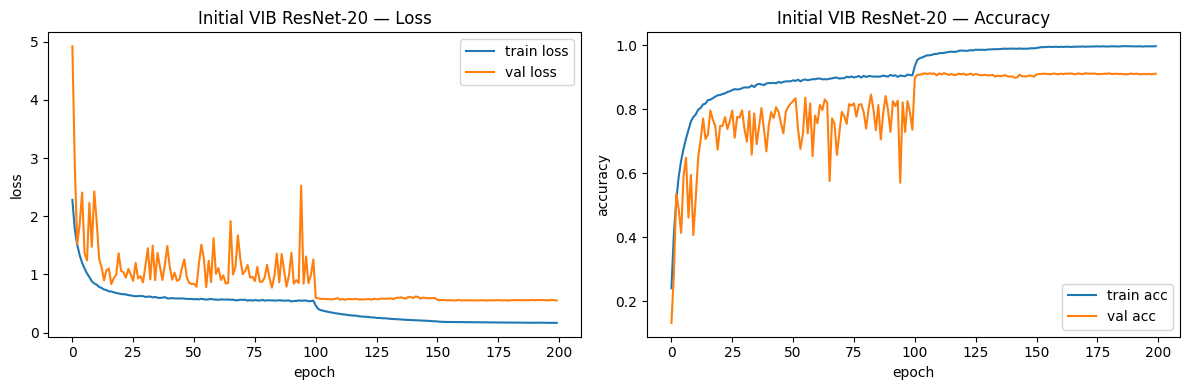

In [13]:
# Plotting initial VIB training curves

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

## Plot 1
ax1.plot(history.history["loss"], label="train loss")
ax1.plot(history.history["val_loss"], label="val loss")
ax1.set_xlabel("epoch"); ax1.set_ylabel("loss")
ax1.set_title("Initial VIB ResNet-20 — Loss"); ax1.legend()

## Plot 2
ax2.plot(history.history["categorical_accuracy"], label="train acc")
ax2.plot(history.history["val_categorical_accuracy"], label="val acc")
ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy")
ax2.set_title("Initial VIB ResNet-20 — Accuracy"); ax2.legend()
plt.tight_layout(); plt.show()


In [14]:
# SWAG helper functions
'''
SWAG is fit after the initial VIB training run. We keep the architecture fixed,
continue training with a constant learning rate, and collect parameter snapshots.

For stability, only trainable variables are sampled. BatchNorm moving means and
moving variances are left at the values learned during SWAG collection. This is
a small practical deviation from sampling every array in model.get_weights(),
because directly sampling BatchNorm moving variances can create negative values.
'''

def flatten_trainable_variables(model):
    return np.concatenate([v.numpy().ravel() for v in model.trainable_variables]).astype("float32")


def set_trainable_variables_from_vector(model, vector):
    pointer = 0
    for variable in model.trainable_variables:
        shape = variable.shape
        size = int(np.prod(shape))
        new_value = vector[pointer:pointer + size].reshape(shape)
        variable.assign(new_value)
        pointer += size

    if pointer != len(vector):
        raise ValueError("Vector length did not match the model's trainable variables.")


def fit_swag_distribution(snapshots):
    snapshots = np.asarray(snapshots, dtype="float32")
    if snapshots.ndim != 2 or snapshots.shape[0] < 2:
        raise ValueError("Need at least two SWAG snapshots to estimate covariance.")

    mean = snapshots.mean(axis=0)
    diag_var = snapshots.var(axis=0, ddof=1)

    ### Low-rank deviations are centred on the *running* mean up to each snapshot
    ### (the Maddox et al. 2019 construction), matching the SWAG-alone notebook.
    ### Centring on the final mean instead systematically overstates the spread.
    deviations = np.empty_like(snapshots)
    for i in range(snapshots.shape[0]):
        deviations[i] = snapshots[i] - snapshots[:i + 1].mean(axis=0)

    return {"mean": mean,
            "diag_var": diag_var,
            "deviations": deviations,
            "n_snapshots": snapshots.shape[0]}


def sample_swag_weights(swag, rng=None, diag_scale=1.0, low_rank_scale=1.0):
    if rng is None:
        rng = np.random.default_rng()

    mean = swag["mean"]
    diag_var = swag["diag_var"]
    deviations = swag["deviations"]
    k = swag["n_snapshots"]

    ### SWAG commonly uses a 1/sqrt(2) split between diagonal and low-rank parts.
    diag_sample = np.sqrt(0.5) * diag_scale * np.sqrt(diag_var + 1e-30) * rng.normal(size=mean.shape)
    low_rank_sample = np.sqrt(0.5) * low_rank_scale * deviations.T @ rng.normal(size=k) / np.sqrt(k - 1)

    return (mean + diag_sample + low_rank_sample).astype("float32")


class SWAGSnapshotCallback(keras.callbacks.Callback):

    def __init__(self, collect_every=2):
        super().__init__()
        self.collect_every = collect_every
        self.snapshots = []

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.collect_every == 0:
            self.snapshots.append(flatten_trainable_variables(self.model))
            print(f"SWAG snapshot {len(self.snapshots)} collected at SWAG epoch {epoch + 1}")


def _all_batchnorm_layers(model):
    """Recursively collect every BatchNormalization layer, including those nested
    inside custom layers (e.g. ResidualBlock). Avoids model.submodules, which is
    not exposed on Functional models in current Keras versions."""
    seen, stack, found = set(), [model], []
    while stack:
        obj = stack.pop()
        if id(obj) in seen:
            continue
        seen.add(id(obj))
        if isinstance(obj, keras.layers.BatchNormalization):
            found.append(obj)
        subs = []
        for attr in ("layers", "_layers"):
            v = getattr(obj, attr, None)
            if v:
                try:
                    subs.extend(list(v))
                except TypeError:
                    pass
        for a in getattr(obj, "__dict__", {}).values():
            if isinstance(a, keras.layers.Layer):
                subs.append(a)
            elif isinstance(a, (list, tuple)):
                subs.extend(x for x in a if isinstance(x, keras.layers.Layer))
        stack.extend(subs)
    out, s2 = [], set()
    for b in found:
        if id(b) not in s2:
            s2.add(id(b)); out.append(b)
    return out


def recalibrate_batchnorm(model, recal_dataset, num_batches=200):
    """Re-estimate BatchNorm moving statistics for the model's CURRENT weights.

    SWAG-sampled weights do not match the BatchNorm running statistics learned
    during training (those belong to the SWA-mean weights). Evaluating with
    mismatched normalisation degrades accuracy and inflates apparent weight
    disagreement. We therefore reset the moving statistics and recompute them
    with a *cumulative* average over training data, taking no gradient steps.

    Setting each BN layer's momentum to i/(i+1) on the i-th batch turns Keras'
    exponential moving average into an exact running mean:
        i=0 -> momentum 0  -> moving = batch_0
        i=1 -> momentum 1/2 -> moving = (batch_0 + batch_1) / 2  ...
    so the reset values never leak into the final estimate. Original momenta are
    restored afterwards. This is the standard SWAG-with-BatchNorm procedure
    (Maddox et al. 2019).
    """
    bn_layers = _all_batchnorm_layers(model)
    original_momenta = [bn.momentum for bn in bn_layers]

    for bn in bn_layers:
        bn.moving_mean.assign(tf.zeros_like(bn.moving_mean))
        bn.moving_variance.assign(tf.ones_like(bn.moving_variance))

    for i, batch in enumerate(recal_dataset):
        if num_batches is not None and i >= num_batches:
            break
        x_batch = batch[0] if isinstance(batch, (tuple, list)) else batch
        for bn in bn_layers:
            bn.momentum = i / (i + 1.0)
        model(x_batch, training=True)   # updates BN running stats only; no optimiser step

    for bn, mom in zip(bn_layers, original_momenta):
        bn.momentum = mom


In [15]:
# SWAG collection training
'''
After initial VIB convergence, we switch to a constant learning rate and keep
training with the same VIB loss. Every c epochs, we take a trainable-weight
snapshot. These snapshots define the SWAG mean, diagonal variance and low-rank
covariance directions.
'''

swag_learning_rate = 0.001  # was 0.01; matches the validated SWAG-alone collection LR (higher rates over-inflate the posterior)
swag_epochs = 40
swag_collect_every = 2

swag_callback = SWAGSnapshotCallback(collect_every=swag_collect_every)

model.compile(optimizer=keras.optimizers.SGD(learning_rate=swag_learning_rate, momentum=0.9),
              loss=keras.losses.CategoricalCrossentropy(from_logits=True),
              metrics=["categorical_accuracy"])

swag_history = model.fit(train_ds,
                         epochs=swag_epochs,
                         validation_data=val_ds,
                         callbacks=[swag_callback])

swag = fit_swag_distribution(swag_callback.snapshots)
set_trainable_variables_from_vector(model, swag["mean"])
model.save_weights("vib_swag_mean.weights.h5")

print(f"Collected {swag['n_snapshots']} SWAG snapshots")
print(f"SWAG parameter dimension: {swag['mean'].shape[0]}")


Epoch 1/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 50ms/step - categorical_accuracy: 0.9951 - loss: 0.1784 - val_categorical_accuracy: 0.9106 - val_loss: 0.5539
Epoch 2/40
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - categorical_accuracy: 0.9960 - loss: 0.1768SWAG snapshot 1 collected at SWAG epoch 2
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - categorical_accuracy: 0.9954 - loss: 0.1775 - val_categorical_accuracy: 0.9111 - val_loss: 0.5534
Epoch 3/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - categorical_accuracy: 0.9950 - loss: 0.1780 - val_categorical_accuracy: 0.9088 - val_loss: 0.5590
Epoch 4/40
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - categorical_accuracy: 0.9948 - loss: 0.1773SWAG snapshot 2 collected at SWAG epoch 4
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - categorical_accuracy: 0.9952 - loss: 0.1770 - val_categorical_accuracy: 0.9092 - val_loss: 0.5567
Epoch 5/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - categorical_accuracy: 0.9947 - loss: 0.1774 - val_categorical_accuracy: 0.

In [16]:
# Loading SVHN as the out-of-distribution reference set
'''
Per the proposal §3.5, SVHN (street view of house numbers) is used as the
OOD test set. SVHN images are 32x32 colour photos like CIFAR-10, but of
digits, so a CIFAR-10 trained model should ideally report higher predictive
entropy on SVHN inputs than on its in-distribution CIFAR-10 test images.

We download the official SVHN test split (.mat) directly instead of using
tensorflow_datasets, which removes a flaky lazy-import dependency from the
pipeline. The ~26k images rescale to [0, 1] to match CIFAR-10 preprocessing.
The file caches in the working directory (Drive) after the first download.
'''
import os, urllib.request
from scipy.io import loadmat

svhn_path = "svhn_test_32x32.mat"
if not os.path.exists(svhn_path):
    urllib.request.urlretrieve(
        "http://ufldl.stanford.edu/housenumbers/test_32x32.mat", svhn_path)

mat = loadmat(svhn_path)
# mat["X"] has shape (32, 32, 3, N); move the sample axis to the front, rescale.
x_svhn = np.transpose(mat["X"], (3, 0, 1, 2)).astype("float32") / 255.0

print(f"SVHN OOD set: {x_svhn.shape}")   # expect (26032, 32, 32, 3)


SVHN OOD set: (26032, 32, 32, 3)


In [17]:
# Generating VIB-SWAG predictions and uncertainty decomposition
'''
This is the full proposal design: for each input, we sample S weight
configurations from SWAG. For each sampled weight configuration, we sample M
representations from the VIB bottleneck. This gives an (S, M, N, 10) probability
array.

The decomposition follows the proposal:
- total uncertainty: entropy of the full averaged predictive distribution,
- weight-epistemic: disagreement between SWAG weight samples,
- bottleneck / representation-level: disagreement between z samples for fixed weights,
- residual: remaining expected entropy with both weights and z fixed.
'''

def entropy_from_probs(probs, eps=1e-12):
    probs = np.clip(probs, eps, 1.0)
    return -np.sum(probs * np.log(probs), axis=-1)


def decompose_uncertainty(all_probs):
    ### all_probs has shape (S, M, N, C)
    mean_probs = all_probs.mean(axis=(0, 1))        # (N, C)
    weight_mean_probs = all_probs.mean(axis=1)      # (S, N, C)

    total = entropy_from_probs(mean_probs)                          # (N,)
    mean_entropy_fixed_weight = entropy_from_probs(weight_mean_probs).mean(axis=0)
    residual = entropy_from_probs(all_probs).mean(axis=(0, 1))

    weight_epistemic = total - mean_entropy_fixed_weight
    bottleneck = mean_entropy_fixed_weight - residual

    ### Small negative values can occur from floating-point error.
    weight_epistemic = np.maximum(weight_epistemic, 0.0)
    bottleneck = np.maximum(bottleneck, 0.0)
    residual = np.maximum(residual, 0.0)

    return {"total": total,
            "weight_epistemic": weight_epistemic,
            "bottleneck": bottleneck,
            "residual": residual}


def predict_vib_swag_double_mc(model, swag, data, n_weight_samples=30, n_rep_samples=10, batch_size=128, recal_dataset=None, seed=1999):
    rng = np.random.default_rng(seed)
    original_weights = flatten_trainable_variables(model)
    all_weight_probs = []

    for s in range(n_weight_samples):
        sampled_weights = sample_swag_weights(swag, rng=rng)
        set_trainable_variables_from_vector(model, sampled_weights)

        ### Refresh BatchNorm statistics for THIS weight sample before predicting.
        if recal_dataset is not None:
            recalibrate_batchnorm(model, recal_dataset, num_batches=200)

        rep_probs = []
        for m in range(n_rep_samples):
            if isinstance(data, tf.data.Dataset):
                logits = model.predict(data, verbose=0)
            else:
                logits = model.predict(data, batch_size=batch_size, verbose=0)

            probs = tf.nn.softmax(logits, axis=-1).numpy()
            rep_probs.append(probs)

        rep_probs = np.stack(rep_probs, axis=0)     # (M, N, 10)
        all_weight_probs.append(rep_probs)
        print(f"SWAG sample {s + 1:02d}/{n_weight_samples} complete")

    set_trainable_variables_from_vector(model, original_weights)

    all_probs = np.stack(all_weight_probs, axis=0)  # (S, M, N, 10)
    mean_probs = all_probs.mean(axis=(0, 1))        # (N, 10)
    uncertainty = decompose_uncertainty(all_probs)

    return mean_probs, all_probs, uncertainty


n_weight_samples = 30
n_rep_samples = 10

## In-distribution: CIFAR-10 test set
probs_test, all_probs_test, uncertainty_test = predict_vib_swag_double_mc(
    model, swag, test_ds,
    recal_dataset=recal_ds,
    n_weight_samples=n_weight_samples,
    n_rep_samples=n_rep_samples,
    batch_size=128,
    seed=1999
)
preds_test = np.argmax(probs_test, axis=1)
labels_test = np.argmax(y_test, axis=1)

print(f"VIB-SWAG double-MC test accuracy: {(preds_test == labels_test).mean():.4f}")

## Out-of-distribution: SVHN test set
probs_svhn, all_probs_svhn, uncertainty_svhn = predict_vib_swag_double_mc(
    model, swag, x_svhn,
    recal_dataset=recal_ds,
    n_weight_samples=n_weight_samples,
    n_rep_samples=n_rep_samples,
    batch_size=128,
    seed=2000
)

print(f"probs_test:          {probs_test.shape}")
print(f"all_probs_test:      {all_probs_test.shape}")
print(f"probs_svhn:          {probs_svhn.shape}")
print(f"all_probs_svhn:      {all_probs_svhn.shape}")
print(f"test total mean:      {uncertainty_test['total'].mean():.4f}")
print(f"test weight mean:     {uncertainty_test['weight_epistemic'].mean():.4f}")
print(f"test bottleneck mean: {uncertainty_test['bottleneck'].mean():.4f}")
print(f"test residual mean:   {uncertainty_test['residual'].mean():.4f}")


SWAG sample 01/30 complete
SWAG sample 02/30 complete
SWAG sample 03/30 complete
SWAG sample 04/30 complete
SWAG sample 05/30 complete
SWAG sample 06/30 complete
SWAG sample 07/30 complete
SWAG sample 08/30 complete
SWAG sample 09/30 complete
SWAG sample 10/30 complete
SWAG sample 11/30 complete
SWAG sample 12/30 complete
SWAG sample 13/30 complete
SWAG sample 14/30 complete
SWAG sample 15/30 complete
SWAG sample 16/30 complete
SWAG sample 17/30 complete
SWAG sample 18/30 complete
SWAG sample 19/30 complete
SWAG sample 20/30 complete
SWAG sample 21/30 complete
SWAG sample 22/30 complete
SWAG sample 23/30 complete
SWAG sample 24/30 complete
SWAG sample 25/30 complete
SWAG sample 26/30 complete
SWAG sample 27/30 complete
SWAG sample 28/30 complete
SWAG sample 29/30 complete
SWAG sample 30/30 complete
VIB-SWAG double-MC test accuracy: 0.9109
SWAG sample 01/30 complete
SWAG sample 02/30 complete
SWAG sample 03/30 complete
SWAG sample 04/30 complete
SWAG sample 05/30 complete
SWAG sample 06

In [18]:
# Saving raw outputs for the evaluation file
'''
Save format (shared across all benchmarks). The evaluation notebook will
load these by filename and produce ECE, reliability diagrams, OOD AUROC,
risk-coverage and uncertainty summaries.

Keys:
  model_name               - human-readable string identifier
  beta                     - VIB compression strength used for training
  latent_dim               - bottleneck dimensionality
  n_weight_samples         - number of SWAG weight samples used at inference
  n_rep_samples            - number of VIB representation samples per weight sample
  probs_test               - (N_test, 10) mean predictive distribution on CIFAR-10 test
  labels_test              - (N_test,) true labels (integer 0-9)
  preds_test               - (N_test,) argmax of probs_test
  probs_svhn               - (N_svhn, 10) mean predictive distribution on SVHN OOD
  all_probs_test           - (S, M, N_test, 10) per-weight/per-representation probs
  all_probs_svhn           - (S, M, N_svhn, 10) per-weight/per-representation probs
  total_*                  - entropy of the averaged predictive distribution
  weight_epistemic_*       - SWAG / weight-level uncertainty component
  bottleneck_*             - VIB representation-level uncertainty component
  residual_*               - remaining expected entropy after fixing weights and z

The large all_probs arrays are included so the decomposition can be recomputed
or audited later. Delete those keys if storage becomes an issue.
'''
np.savez("vib_swag_results.npz",
         model_name="vib_swag",
         beta=beta,
         latent_dim=latent_dim,
         swag_learning_rate=swag_learning_rate,
         swag_epochs=swag_epochs,
         swag_collect_every=swag_collect_every,
         n_swag_snapshots=swag["n_snapshots"],
         n_weight_samples=n_weight_samples,
         n_rep_samples=n_rep_samples,
         probs_test=probs_test,
         labels_test=labels_test,
         preds_test=preds_test,
         probs_svhn=probs_svhn,
         all_probs_test=all_probs_test,
         all_probs_svhn=all_probs_svhn,
         total_test=uncertainty_test["total"],
         weight_epistemic_test=uncertainty_test["weight_epistemic"],
         bottleneck_test=uncertainty_test["bottleneck"],
         residual_test=uncertainty_test["residual"],
         total_svhn=uncertainty_svhn["total"],
         weight_epistemic_svhn=uncertainty_svhn["weight_epistemic"],
         bottleneck_svhn=uncertainty_svhn["bottleneck"],
         residual_svhn=uncertainty_svhn["residual"])

np.savez("vib_swag_distribution.npz",
         mean=swag["mean"],
         diag_var=swag["diag_var"],
         deviations=swag["deviations"],
         n_snapshots=swag["n_snapshots"])

print("Saved vib_swag_results.npz")
print("Saved vib_swag_distribution.npz")


Saved vib_swag_results.npz
Saved vib_swag_distribution.npz
